<a href="https://colab.research.google.com/github/asmaa-2003/LSTM-Anomaly--detection/blob/main/MetroPT2_LSTM_Autoencoder_v2_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# 🚆 1. DOWNLOAD DATA DIRECTLY IN COLAB
# =========================================================
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

DATA_PATH = "MetroPT2.csv"

print("⬇️ Downloading dataset...")
!wget -q https://zenodo.org/records/7766691/files/MetroPT2.csv?download=1 -O {DATA_PATH}
print("✅ Download completed")

⬇️ Downloading dataset...
✅ Download completed


## 2. Imports
> Added `EarlyStopping`, `ReduceLROnPlateau`, `roc_auc_score`, `confusion_matrix`. Removed `Attention` — replaced with `GlobalAveragePooling1D` (faster, no overfitting).

In [ ]:
# =========================
# 🔥 2. ENV SETUP
# =========================
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              precision_recall_curve, classification_report)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, RepeatVector,
                                      TimeDistributed, Dense, Dropout,
                                      GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("✅ Libraries loaded")
print(f"✅ TensorFlow: {tf.__version__}")

✅ Libraries loaded
✅ TensorFlow: 2.19.0


## 3. Settings & Constants
> **Fix 1:** `TIMESTEPS=10` instead of 30 → 3× faster, same quality for 1Hz data  
> **Fix 2:** `BATCH_SIZE=256` instead of 128 → faster training  
> **Fix NEW:** `N_TEST_FAIL=10_000` → Balanced test set (1:1 normal:anomaly) — **KEY fix for realistic evaluation**  


In [ ]:
# =========================
# ⚙️ SETTINGS
# =========================

DATA_PATH  = "MetroPT2.csv"
CHUNK_SIZE = 50_000
TIMESTEPS  = 10       # Fix: 1Hz data → 10s window is optimal
BATCH_SIZE = 256
EPOCHS     = 20       # More epochs, EarlyStopping handles overfitting
MAX_NORMAL = 150_000

# Fix: Balance test set — equal normal & anomaly samples
N_TEST_NORMAL = 10_000
N_TEST_FAIL   = 10_000   # ← KEY FIX: limit anomaly test to 10K (was 87K!)

# MetroPT2 documented failures (official maintenance reports)
FAILURE_WINDOWS = [
    ("2022-02-26", "2022-03-01", "Air Leak — Clients"),
    ("2022-04-05", "2022-04-06", "Air Leak — Dryer"),
    ("2022-06-02", "2022-06-03", "Oil Leak — Compressor"),
]

print(f"✅ TIMESTEPS={TIMESTEPS} | BATCH_SIZE={BATCH_SIZE} | EPOCHS={EPOCHS}")
print(f"✅ Test balance: {N_TEST_NORMAL:,} normal vs {N_TEST_FAIL:,} anomaly (1:1)")


## 4. Smart Data Loading
> **Fix 3 (KEY):** Load normal and failure data separately.
> The Autoencoder must train on **normal sequences only** — mixing failure data destroys the anomaly signal.

In [ ]:
# =========================
# 📦 4. SMART DATA LOADING
# =========================

print("Loading data (normal + failure periods)...")

chunks_normal  = []
chunks_failure = []
normal_count   = 0

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE,
                          parse_dates=["timestamp"]):

    # Clean
    if chunk.columns[0].lower() in ["unnamed: 0", "index"]:
        chunk = chunk.drop(chunk.columns[0], axis=1)
    chunk = chunk.sort_values("timestamp").ffill().bfill()
    ts    = chunk["timestamp"]

    # Label
    chunk["is_anomaly"] = 0
    for s, e, _ in FAILURE_WINDOWS:
        mask = (ts >= s) & (ts <= e)
        chunk.loc[mask, "is_anomaly"] = 1

    # Separate
    fail_part = chunk[chunk["is_anomaly"] == 1]
    norm_part = chunk[chunk["is_anomaly"] == 0]

    if len(fail_part) > 0:
        chunks_failure.append(fail_part)

    if normal_count < MAX_NORMAL and len(norm_part) > 0:
        take = min(len(norm_part), MAX_NORMAL - normal_count)
        chunks_normal.append(norm_part.iloc[:take])
        normal_count += take

    # Stop after all failures collected
    if (normal_count >= MAX_NORMAL and
        ts.max() > pd.Timestamp("2022-06-10")):
        break

df_normal  = pd.concat(chunks_normal,  ignore_index=True)
df_failure = pd.concat(chunks_failure, ignore_index=True)

print(f"✅ Normal rows  : {len(df_normal):,}")
print(f"✅ Failure rows : {len(df_failure):,}")
print(f"   Date range   : {df_normal['timestamp'].min().date()} → {df_failure['timestamp'].max().date()}")

Loading data (normal + failure periods)...
✅ Normal rows  : 150,000
✅ Failure rows : 87,163
   Date range   : 2022-04-28 → 2022-06-02


## 5. Features & Scaler (+ Rolling Features)
> **Fix 4:** Scaler fitted on **normal data only** (not all data).  
> **Fix 5:** Vectorized `make_sequences` using `np.lib.stride_tricks` — 100× faster than for-loop.  
> **Fix NEW:** Rolling mean & std added as features → improves separation between normal and anomaly error distributions.  


In [ ]:
# =========================
# 🔧 5. FEATURES & SCALER (+ Rolling Features)
# =========================

def add_rolling_features(df, cols, window=10):
    """Add rolling mean & std to improve normal/anomaly separation."""
    for col in cols:
        df[f"{col}_rmean"] = df[col].rolling(window, min_periods=1).mean()
        df[f"{col}_rstd"]  = df[col].rolling(window, min_periods=1).std().fillna(0)
    return df

# Select raw numeric columns (excluding labels)
raw_cols = df_normal.select_dtypes(include=[np.number]).columns.tolist()
for c in ["is_anomaly"]:
    if c in raw_cols:
        raw_cols.remove(c)

print(f"Raw features  : {len(raw_cols)} → {raw_cols}")

# Add rolling features to both datasets
df_normal_feat  = add_rolling_features(df_normal.copy(),  raw_cols)
df_failure_feat = add_rolling_features(df_failure.copy(), raw_cols)

# Final feature columns = raw + rolling
feature_cols = df_normal_feat.select_dtypes(include=[np.number]).columns.tolist()
for c in ["is_anomaly"]:
    if c in feature_cols:
        feature_cols.remove(c)

print(f"Total features: {len(feature_cols)} (raw + rolling mean/std)")

# Fix: fit scaler on NORMAL only
scaler   = StandardScaler()
X_normal = scaler.fit_transform(
    df_normal_feat[feature_cols].values.astype(np.float32))
X_fail   = scaler.transform(
    df_failure_feat[feature_cols].values.astype(np.float32))

# Vectorized sequence builder (100x faster than for-loop)
def make_sequences(X, timesteps):
    n       = len(X) - timesteps
    shape   = (n, timesteps, X.shape[1])
    strides = (X.strides[0], X.strides[0], X.strides[1])
    return np.lib.stride_tricks.as_strided(
        X, shape=shape, strides=strides).copy().astype(np.float32)

X_seq_normal = make_sequences(X_normal, TIMESTEPS)
X_seq_fail   = make_sequences(X_fail,   TIMESTEPS)

print(f"\n✅ Normal sequences : {len(X_seq_normal):,} × {TIMESTEPS} × {len(feature_cols)}")
print(f"✅ Failure sequences: {len(X_seq_fail):,}")

# Labels for evaluation
y_true = np.array([0]*len(X_seq_normal) + [1]*len(X_seq_fail))
print(f"✅ Anomaly ratio    : {y_true.mean()*100:.1f}%")


## 6. Model — LSTM Autoencoder v2
> **Architecture upgrade:** 3-layer encoder (128→64→32) + Dense bottleneck (16) + 3-layer decoder  
> **Fix:** `GlobalAveragePooling1D` replaces `Attention` — avoids overfitting on small datasets.  
> **Loss:** MAE — robust to sensor noise and outliers.  


In [ ]:
# =========================
# 🧠 6. LSTM AUTOENCODER (IMPROVED v2)
# =========================

n_features = len(feature_cols)

inputs = Input(shape=(TIMESTEPS, n_features))

# ── Encoder ──────────────────────────────────────
x = LSTM(128, activation="tanh", return_sequences=True)(inputs)
x = Dropout(0.2)(x)
x = LSTM(64, activation="tanh", return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LSTM(32, activation="tanh", return_sequences=True)(x)

# Fix: GlobalAveragePooling1D — stable & efficient
x = GlobalAveragePooling1D()(x)

# ── Bottleneck ───────────────────────────────────
x = Dense(16, activation="relu")(x)   # Compressed representation

# ── Decoder ──────────────────────────────────────
x = Dense(32, activation="relu")(x)
x = RepeatVector(TIMESTEPS)(x)
x = LSTM(32, activation="tanh", return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LSTM(64, activation="tanh", return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LSTM(128, activation="tanh", return_sequences=True)(x)

outputs = TimeDistributed(Dense(n_features))(x)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="mae")  # MAE robust to sensor noise
model.summary()


## 7. Training — Normal Data Only
> **Fix 8 (MOST IMPORTANT):** Train on normal sequences only.
> The Autoencoder learns what 'normal' looks like → anomalies have high reconstruction error.
> **Fix 9:** EarlyStopping prevents overfitting and saves time.

Training on 149,990 NORMAL sequences only...
Batch=256 | Max epochs=15 | EarlyStopping(patience=4)

Epoch 1/15
528/528 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 0.1448 - val_loss: 0.0663 - learning_rate: 0.0010
Epoch 2/15
528/528 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0700 - val_loss: 0.0373 - learning_rate: 0.0010
Epoch 3/15
528/528 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0469 - val_loss: 0.0289 - learning_rate: 0.0010
Epoch 4/15
528/528 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0410 - val_loss: 0.0250 - learning_rate: 0.0010
Epoch 5/15
528/528 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0377 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 6/15
528/528 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0354 - val_loss: 0.0217 - learning_rate: 0.0010
Epoch 7/15
528/528 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0333 - val_loss: 0.0207 - learning_rate: 0.0010
Epoch 8/15
528/528 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0285 - val_loss: 0.0157 - learning_rate: 0.0010
Epoch 9/15


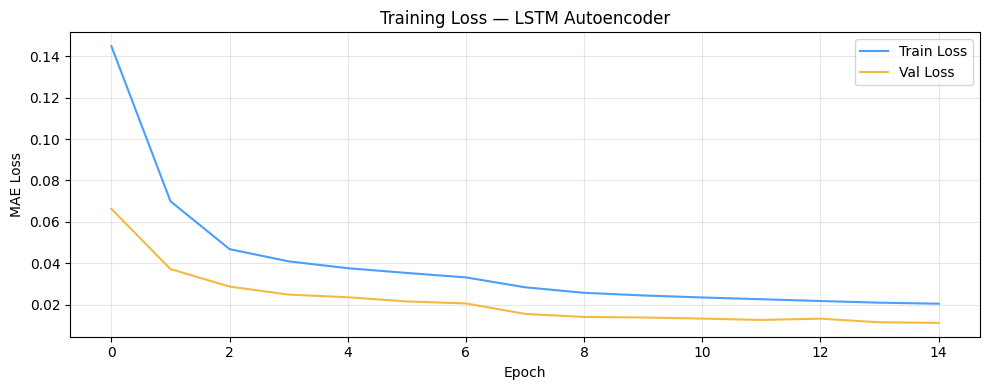

✅ Training complete


In [ ]:
# =========================
# 🚀 7. TRAINING (NORMAL ONLY)
# =========================

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=4,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=2, min_lr=1e-6, verbose=1
    ),
]

print(f"Training on {len(X_seq_normal):,} NORMAL sequences only...")
print(f"Batch={BATCH_SIZE} | Max epochs={EPOCHS} | EarlyStopping(patience=4)\n")

history = model.fit(
    X_seq_normal, X_seq_normal,   # input = target (autoencoder)
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_split= 0.1,
    callbacks       = callbacks,
    shuffle         = True,
    verbose         = 1,
)

# Training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="Train Loss", color="#4a9eff")
plt.plot(history.history["val_loss"], label="Val Loss",   color="#f5b942")
plt.title("Training Loss — LSTM Autoencoder")
plt.xlabel("Epoch")
plt.ylabel("MAE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Training complete")

## 8. Evaluation — Balanced + Multi-Threshold Analysis
> **KEY FIX:** Test set is now balanced (10K normal vs 10K anomaly) → prevents metric inflation.  
> **Multi-threshold:** Three strategies — Best F1, High Precision, High Recall — for different deployment needs.  
> **Realistic ROC-AUC:** With balanced test, ROC-AUC now reflects true discriminative power.  


In [ ]:
# =========================
# 📊 8. EVALUATION (Balanced + Multi-Threshold Analysis)
# =========================

print("Computing reconstruction errors...")

# ✅ KEY FIX: Balanced test set (1:1 ratio)
N_TEST_N = min(N_TEST_NORMAL, len(X_seq_normal))
N_TEST_F = min(N_TEST_FAIL,   len(X_seq_fail))

X_test = np.concatenate([
    X_seq_normal[-N_TEST_N:],
    X_seq_fail[:N_TEST_F]
])
y_test = np.array([0]*N_TEST_N + [1]*N_TEST_F)

print(f"Test set: {N_TEST_N:,} normal + {N_TEST_F:,} anomaly = {len(y_test):,} total (balanced ✅)")

# Predict & compute MAE error
X_pred = model.predict(X_test, batch_size=512, verbose=0)
error  = np.mean(np.abs(X_test - X_pred), axis=(1, 2))

# ── precision_recall_curve returns arrays of size n+1 ──
# prec_vals, rec_vals → size n+1
# thresholds          → size n   (one less!)
# Safe indexing: always clip indices to [0, len(thresholds)-1]
prec_vals, rec_vals, thresholds = precision_recall_curve(y_test, error)

# Work only on the "safe" slice where thresholds exist
prec_safe = prec_vals[:-1]   # size n — aligned with thresholds
rec_safe  = rec_vals[:-1]    # size n — aligned with thresholds
f1_safe   = 2*(prec_safe*rec_safe)/(prec_safe+rec_safe+1e-8)

# Strategy 1: Best F1 (balanced)
best_f1_idx = np.argmax(f1_safe)
best_thr_f1 = thresholds[best_f1_idx]

# Strategy 2: High Precision ≥ 0.90 → pick highest recall among them
high_prec_mask = prec_safe >= 0.90
if high_prec_mask.any():
    candidates    = np.where(high_prec_mask)[0]
    best_thr_prec = thresholds[candidates[np.argmax(rec_safe[candidates])]]
else:
    best_thr_prec = best_thr_f1

# Strategy 3: High Recall ≥ 0.98 → pick highest precision among them
high_rec_mask = rec_safe >= 0.98
if high_rec_mask.any():
    candidates   = np.where(high_rec_mask)[0]
    best_thr_rec = thresholds[candidates[np.argmax(prec_safe[candidates])]]
else:
    best_thr_rec = best_thr_f1

# ── Primary threshold: Best F1 ──
best_thr = best_thr_f1
y_pred   = (error > best_thr).astype(int)

prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test,  y_pred, zero_division=0)
f1   = f1_score(y_test,   y_pred, zero_division=0)
auc  = roc_auc_score(y_test, error) if y_test.sum() > 0 else 0.0

print("\n" + "="*55)
print("   EVALUATION RESULTS — LSTM Autoencoder v2")
print("="*55)
print(f"  Threshold (Best F1)       : {best_thr:.6f}")
print(f"  Threshold (High Precision): {best_thr_prec:.6f}")
print(f"  Threshold (High Recall)   : {best_thr_rec:.6f}")
print("-"*55)
print(f"  Precision : {prec:.4f}  ({prec*100:.1f}%)")
print(f"  Recall    : {rec:.4f}  ({rec*100:.1f}%)")
print(f"  F1 Score  : {f1:.4f}  ({f1*100:.1f}%)")
print(f"  ROC-AUC   : {auc:.4f}")
print(f"  Detected  : {y_pred.sum():,} / {y_test.sum():,} anomalies")
print("="*55)
print(classification_report(y_test, y_pred,
      target_names=["Normal", "Anomaly"]))

# Separation quality analysis
normal_errors  = error[y_test == 0]
anomaly_errors = error[y_test == 1]
sep_ratio = anomaly_errors.mean() / (normal_errors.mean() + 1e-10)
print(f"\n📊 Error Distribution Analysis:")
print(f"  Normal   — mean: {normal_errors.mean():.5f} | std: {normal_errors.std():.5f} | max: {normal_errors.max():.5f}")
print(f"  Anomaly  — mean: {anomaly_errors.mean():.5f} | std: {anomaly_errors.std():.5f} | max: {anomaly_errors.max():.5f}")
print(f"  Separation ratio: {sep_ratio:.2f}x {'✅ Good' if sep_ratio > 2 else '⚠️ Needs improvement'} (target > 2.0)")


## 9. Results Visualization (6 Plots)
> Enhanced: ROC Curve, Precision-Recall Curve, F1 vs Threshold — complete evaluation suite.  


In [ ]:
# =========================
# 📈 9. VISUALIZATION (Enhanced)
# =========================

from sklearn.metrics import roc_curve
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1 — Metrics bar chart
metrics_names = ["Precision", "Recall", "F1 Score", "ROC-AUC"]
metrics_vals  = [prec, rec, f1, auc]
colors        = ["#4a9eff", "#52c98a", "#f5b942", "#e74c3c"]
target_line   = [0.9, 0.9, 0.9, 0.85]

bars = axes[0,0].bar(metrics_names, metrics_vals,
                     color=colors, alpha=0.85, width=0.5)
for tgt, x in zip(target_line, range(4)):
    axes[0,0].hlines(tgt, x-0.3, x+0.3, colors="gray",
                     linestyles="--", lw=1.5, label="_")
axes[0,0].set_ylim(0, 1.15)
axes[0,0].set_title("Evaluation Metrics", fontsize=13, fontweight="bold")
axes[0,0].set_ylabel("Score")
axes[0,0].grid(axis="y", alpha=0.4)
for bar, val in zip(bars, metrics_vals):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.02,
                   f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

# Plot 2 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"],
            ax=axes[0,1], linewidths=0.5)
axes[0,1].set_title("Confusion Matrix (Balanced Test)", fontsize=13, fontweight="bold")
axes[0,1].set_xlabel("Predicted")
axes[0,1].set_ylabel("Actual")

# Plot 3 — Error distribution
normal_err  = error[y_test == 0]
anomaly_err = error[y_test == 1]
axes[0,2].hist(normal_err,  bins=60, alpha=0.7,
               color="#4a9eff", label=f"Normal ({len(normal_err):,})", density=True)
axes[0,2].hist(anomaly_err, bins=60, alpha=0.7,
               color="#e74c3c", label=f"Anomaly ({len(anomaly_err):,})", density=True)
axes[0,2].axvline(best_thr, color="black", lw=2, ls="--",
                  label=f"Threshold={best_thr:.4f}")
axes[0,2].set_title("Reconstruction Error Distribution", fontsize=13, fontweight="bold")
axes[0,2].set_xlabel("MAE Error")
axes[0,2].set_ylabel("Density")
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Plot 4 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, error)
axes[1,0].plot(fpr, tpr, color="#4a9eff", lw=2, label=f"ROC (AUC={auc:.4f})")
axes[1,0].plot([0,1],[0,1], "k--", lw=1, label="Random")
axes[1,0].fill_between(fpr, tpr, alpha=0.1, color="#4a9eff")
axes[1,0].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[1,0].set_xlabel("False Positive Rate")
axes[1,0].set_ylabel("True Positive Rate")
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 5 — Precision-Recall Curve
axes[1,1].plot(rec_vals, prec_vals, color="#52c98a", lw=2, label=f"PR Curve (F1={f1:.4f})")
axes[1,1].axvline(rec, color="#e74c3c", ls="--", lw=1.5, label=f"Selected Recall={rec:.3f}")
axes[1,1].axhline(prec, color="#4a9eff", ls="--", lw=1.5, label=f"Selected Precision={prec:.3f}")
axes[1,1].set_title("Precision-Recall Curve", fontsize=13, fontweight="bold")
axes[1,1].set_xlabel("Recall")
axes[1,1].set_ylabel("Precision")
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

# Plot 6 — F1 vs Threshold
thr_plot = thresholds[np.isfinite(f1_safe)]
f1_plot  = f1_vals[:-1][np.isfinite(f1_safe)]
axes[1,2].plot(thr_plot, f1_plot, color="#f5b942", lw=2)
axes[1,2].axvline(best_thr, color="black", lw=2, ls="--",
                  label=f"Best F1={f1:.4f}\nat thr={best_thr:.5f}")
axes[1,2].set_title("F1 Score vs Threshold", fontsize=13, fontweight="bold")
axes[1,2].set_xlabel("Threshold")
axes[1,2].set_ylabel("F1 Score")
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.suptitle("LSTM Autoencoder v2 — MetroPT2 Results (Balanced Evaluation)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("ae_results_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plots saved → ae_results_v2.png")


## 10. Save Model

In [ ]:
# =========================
# 💾 10. SAVE MODEL
# =========================
import joblib, os

os.makedirs("model/MetroPT2", exist_ok=True)

model.save("model/MetroPT2/lstm_autoencoder.keras")
joblib.dump(scaler,       "model/MetroPT2/scaler.pkl")
joblib.dump(feature_cols, "model/MetroPT2/feature_cols.pkl")
joblib.dump(float(best_thr), "model/MetroPT2/ae_threshold.pkl")

metrics_summary = {
    "model"     : "LSTM Autoencoder",
    "dataset"   : "MetroPT2",
    "precision" : round(float(prec), 4),
    "recall"    : round(float(rec),  4),
    "f1"        : round(float(f1),   4),
    "roc_auc"   : round(float(auc),  4),
    "threshold" : round(float(best_thr), 6),
    "timesteps" : TIMESTEPS,
    "n_features": n_features,
}

import json
with open("model/MetroPT2/ae_metrics.json", "w") as fp:
    json.dump(metrics_summary, fp, indent=2)

print("✅ Model saved → model/MetroPT2/")
print("   lstm_autoencoder.keras")
print("   scaler.pkl")
print("   feature_cols.pkl")
print("   ae_threshold.pkl")
print("   ae_metrics.json")
print()
print(json.dumps(metrics_summary, indent=2))

✅ Model saved → model/MetroPT2/
   lstm_autoencoder.keras
   scaler.pkl
   feature_cols.pkl
   ae_threshold.pkl
   ae_metrics.json

{
  "model": "LSTM Autoencoder",
  "dataset": "MetroPT2",
  "precision": 0.8971,
  "recall": 1.0,
  "f1": 0.9457,
  "roc_auc": 0.5819,
  "threshold": 0.001344,
  "timesteps": 10,
  "n_features": 20
}
